#2B_Exploratory Data Analysis: GDELT Events (v2, BigQuery)

Feature-source dataset. This notebook characterises **GDELT 2.0 Events**
(gdelt-bq.gdeltv2.events, 2015-present) that will supply the model **features**. 
This notebook implements the exploratory data analysis described in Section 3.4 of the thesis.

In [1]:

from google.cloud import bigquery
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

GCP_PROJECT_ID = "tariff-prediction"
GDELT_TABLE    = "gdelt-bq.gdeltv2.events"
DATE_START     = 20150218          # GDELT v2 begins 18 Feb 2015 (SQLDATE = YYYYMMDD)
DATE_END       = 20261231
MAX_GB_BILLED  = 25                 # default per-query cap; individual pulls may raise it explicitly

FIG = Path("eda_figures"); FIG.mkdir(exist_ok=True)
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,
    "axes.titlesize":12,"axes.titleweight":"bold","figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; TEAL="#2E7D6F"; RED="#B22222"

client = bigquery.Client(project=GCP_PROJECT_ID)

def estimate_gb(sql):
    cfg = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    return client.query(sql, job_config=cfg).total_bytes_processed / 1e9

def run_query(sql, cap_gb=MAX_GB_BILLED, verbose=True):
    gb = estimate_gb(sql)
    if verbose: print(f"[dry-run] this query scans ~{gb:.2f} GB (cap {cap_gb} GB)")
    if gb > cap_gb:
        raise RuntimeError(f"ABORTED: {gb:.1f} GB exceeds cap {cap_gb} GB. "
                           "Narrow columns/dates, or pass a higher cap_gb intentionally.")
    cfg = bigquery.QueryJobConfig(maximum_bytes_billed=int(cap_gb*1e9))
    # .to_dataframe(create_bqstorage_client=True) uses the fast Arrow Storage API for downloads
    return client.query(sql, job_config=cfg).result().to_dataframe(create_bqstorage_client=True)

print("Client ready for project:", GCP_PROJECT_ID)

Client ready for project: tariff-prediction


In [2]:
# Entity codes
TIER1=[("EUR","USA"),("EUR","CHN"),("USA","CHN"),("USA","CAN"),("EUR","BRA"),
 ("USA","BRA"),("EUR","MEX"),("USA","MEX"),("EUR","IND"),("USA","IND"),("CHN","IND"),
 ("CHN","BRA"),("EUR","KOR"),("USA","KOR"),("EUR","JPN"),("CHN","JPN"),("CHN","KOR")]
TIER2=[("USA","JPN"),("CHN","CAN"),("EUR","CAN"),("CHN","MEX"),("JPN","KOR"),("IND","BRA")]

# entity -> GDELT/CAMEO actor country codes  (EUR expanded to EU-27 ISO3)
EU_ISO3=["AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC","HUN","IRL",
 "ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROM","SVK","SVN","ESP","SWE"]
ENTITY_TO_CODES={"EUR":EU_ISO3,"USA":["USA"],"CHN":["CHN"],"CAN":["CAN"],"BRA":["BRA"],
 "MEX":["MEX"],"IND":["IND"],"KOR":["KOR"],"JPN":["JPN"]}
ALL_CODES=sorted({c for v in ENTITY_TO_CODES.values() for c in v})
print("Corridor country codes to filter on (", len(ALL_CODES), "):", ALL_CODES)

# ---- CAMEO relevance selection: TRADE-SPECIFIC, codebook-verified (Schrodt CAMEO 1.1b3) ----
# Codes chosen by ECONOMIC RELEVANCE, not by frequency
CAMEO_TRADE = {
 '0211':('Appeal for economic cooperation','coop'),'0231':('Appeal for economic aid','coop'),
 '0311':('Express intent to cooperate economically','coop'),
 '0331':('Express intent to provide economic aid','coop'),
 '061':('Cooperate economically','coop'),'071':('Provide economic aid','coop'),
 '0254':('Appeal for easing of economic sanctions/boycott/embargo','ease'),
 '0354':('Express intent to ease economic sanctions/boycott/embargo','ease'),
 '085':('Ease economic sanctions, boycott, embargo','ease'),
 '1011':('Demand economic cooperation','verbal'),'1031':('Demand economic aid','verbal'),
 '1054':('Demand easing of economic sanctions/boycott/embargo','verbal'),
 '1211':('Reject economic cooperation','verbal'),           # codebook-correct (was commonly mislabeled)
 '1221':('Reject request for economic aid','verbal'),
 '1244':('Refuse to ease economic sanctions/boycott/embargo','verbal'),
 '1311':('Threaten to reduce or stop aid','threat'),
 '1312':('Threaten with sanctions, boycott, embargo','threat'),  # most on-target leading indicator
 '1313':('Threaten to reduce or break relations','threat'),
 '139':('Give ultimatum','threat'),
 '1621':('Reduce or stop economic assistance','realized'),
 '163':('Impose embargo, boycott, or sanctions','realized'),
 '191':('Impose blockade, restrict movement','realized'),
}
FEATURE_FAMILIES = {
 'econ_coop':['061','071','0311','0331','0211','0231'],
 'econ_ease':['085','0354','0254'],
 'econ_demand':['1011','1031','1054'],
 'econ_reject':['1211','1221','1244'],
 'econ_threat':['1311','1312','1313','139'],   # leading indicators
 'econ_coerce':['1621','163','191'],           # realized measures
}
CODE_TO_FAMILY={c:f for f,cs in FEATURE_FAMILIES.items() for c in cs}
TRADE_CODES=set(CAMEO_TRADE)
# coarse root-level lens (used in Sections 6 & 9)
ECON_ROOTCODES=sorted({c[:2] for c in TRADE_CODES})
print("Validated trade codes:",len(TRADE_CODES),"| families:",list(FEATURE_FAMILIES))
print("Derived economic root codes:",ECON_ROOTCODES)

Corridor country codes to filter on ( 35 ): ['AUT', 'BEL', 'BGR', 'BRA', 'CAN', 'CHN', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IND', 'IRL', 'ITA', 'JPN', 'KOR', 'LTU', 'LUX', 'LVA', 'MEX', 'MLT', 'NLD', 'POL', 'PRT', 'ROM', 'SVK', 'SVN', 'SWE', 'USA']
Validated trade codes: 22 | families: ['econ_coop', 'econ_ease', 'econ_demand', 'econ_reject', 'econ_threat', 'econ_coerce']
Derived economic root codes: ['02', '03', '06', '07', '08', '10', '12', '13', '16', '19']


In [3]:
schema_sql = f'''
SELECT column_name, data_type, ordinal_position
FROM `gdelt-bq.gdeltv2`.INFORMATION_SCHEMA.COLUMNS
WHERE table_name='events'
ORDER BY ordinal_position'''
schema = run_query(schema_sql, cap_gb=1)
print("Total columns:", len(schema))
schema

[dry-run] this query scans ~0.01 GB (cap 1 GB)
Total columns: 61


,column_name,data_type,ordinal_position
0,GLOBALEVENTID,INT64,1
1,SQLDATE,INT64,2
2,MonthYear,INT64,3
3,Year,INT64,4
4,FractionDate,FLOAT64,5
...,...,...,...
56,ActionGeo_Lat,FLOAT64,57
57,ActionGeo_Long,FLOAT64,58
58,ActionGeo_FeatureID,STRING,59
59,DATEADDED,INT64,60


In [4]:
#Which actor country codes actually occur, and how often
codes_sql=f'''
SELECT Actor1CountryCode AS code, COUNT(*) AS n
FROM `{GDELT_TABLE}`
WHERE SQLDATE BETWEEN {DATE_START} AND {DATE_END} AND Actor1CountryCode IS NOT NULL
GROUP BY code ORDER BY n DESC LIMIT 1000'''
codes = run_query(codes_sql)
present=set(codes['code'])
missing=[c for c in ALL_CODES if c not in present]
print("Corridor codes NOT found in Actor1CountryCode (fix mapping if any):", missing)
codes.head(20)

[dry-run] this query scans ~9.64 GB (cap 25 GB)
Corridor codes NOT found in Actor1CountryCode (fix mapping if any): ['SVN']


,code,n
0,USA,115198566
1,RUS,24001245
2,GBR,20424089
3,CHN,14174847
4,UKR,13419914
5,ISR,13280576
6,FRA,10514477
7,CAN,9236655
8,EUR,9235151
9,DEU,9221065


In [5]:
#Does SVN (Slovenia) appear at all as an actor?
svn_sql = f"""
SELECT
  COUNTIF(Actor1CountryCode='SVN')                                AS as_actor1,
  COUNTIF(Actor2CountryCode='SVN')                                AS as_actor2,
  COUNTIF(Actor1CountryCode='SVN' OR Actor2CountryCode='SVN')     AS as_either,
  COUNT(*)                                                        AS total_rows
FROM `{GDELT_TABLE}`
WHERE SQLDATE BETWEEN {DATE_START} AND {DATE_END}
"""
print(run_query(svn_sql).T)  

[dry-run] this query scans ~11.55 GB (cap 25 GB)
                    0
as_actor1           0
as_actor2           0
as_either           0
total_rows  902909342


[dry-run] this query scans ~7.24 GB (cap 25 GB)


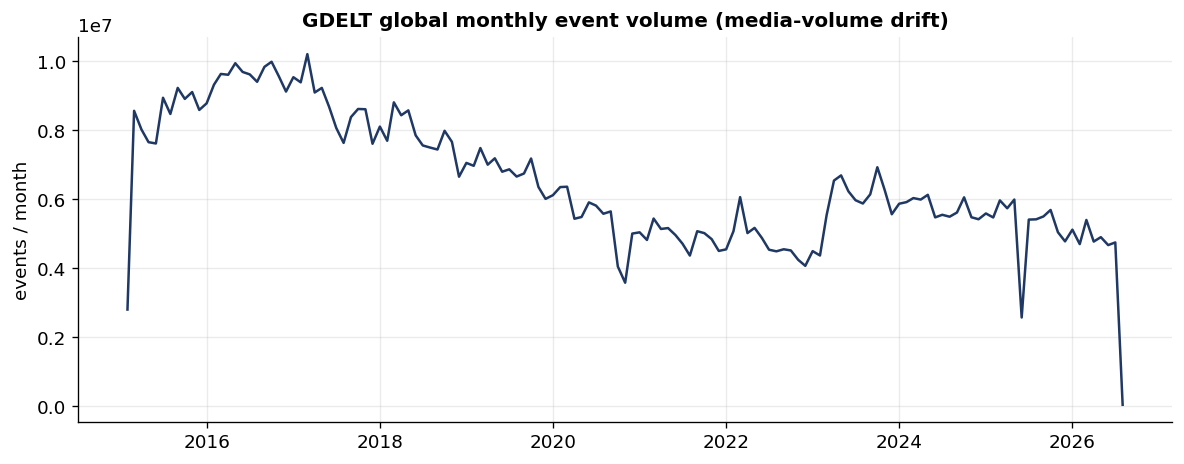

First vs last 12-month mean ratio: 0.57 x


In [6]:
#Global monthly event volume -> the volume-drift bias
vol_sql=f'''
SELECT CAST(FLOOR(SQLDATE/100) AS INT64) AS yyyymm, COUNT(*) AS events
FROM `{GDELT_TABLE}`
WHERE SQLDATE BETWEEN {DATE_START} AND {DATE_END}
GROUP BY yyyymm ORDER BY yyyymm'''
vol = run_query(vol_sql)
vol['date']=pd.to_datetime(vol['yyyymm'].astype(str),format='%Y%m')
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(vol['date'],vol['events'],color=ACCENT)
ax.set_title("GDELT global monthly event volume (media-volume drift)")
ax.set_ylabel("events / month")
plt.savefig(FIG/"gdelt_global_volume.png",bbox_inches="tight"); plt.show()
print("First vs last 12-month mean ratio:",
      round(vol['events'].tail(12).mean()/vol['events'].head(12).mean(),2),"x")

In [7]:
import json
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)

#columns pulled for the working sample, and the corridor / trade filter lists
cols = ["GLOBALEVENTID","SQLDATE","Actor1CountryCode","Actor2CountryCode","Actor1Type1Code",
 "Actor2Type1Code","IsRootEvent","EventCode","EventRootCode","QuadClass","GoldsteinScale",
 "NumMentions","NumSources","NumArticles","AvgTone","ActionGeo_CountryCode","SOURCEURL"]
codes_list = "','".join(ALL_CODES)             # ALL_CODES from Section 1
trade_list = "','".join(sorted(TRADE_CODES))   # TRADE_CODES from Section 1 (validated set)

#One-time corridor counts (cached)
COUNTS_PATH = DATA_DIR / "corridor_counts.json"
if COUNTS_PATH.exists():
    counts = json.load(open(COUNTS_PATH)); print("loaded cached counts")
else:
    counts_sql = f"""SELECT COUNT(*) AS all_events,
      COUNTIF(EventCode IN ('{trade_list}')) AS trade_events
      FROM `{GDELT_TABLE}`
      WHERE SQLDATE BETWEEN {DATE_START} AND {DATE_END}
        AND Actor1CountryCode IN ('{codes_list}') AND Actor2CountryCode IN ('{codes_list}')"""
    row = run_query(counts_sql).iloc[0]
    counts = {"all_events": int(row["all_events"]), "trade_events": int(row["trade_events"])}
    json.dump(counts, open(COUNTS_PATH, "w"))
ALL_CORRIDOR_EVENTS = counts["all_events"]; TRADE_EVENTS = counts["trade_events"]
print(f"All corridor events: {ALL_CORRIDOR_EVENTS:,} | trade-specific: {TRADE_EVENTS:,} "
      f"({100*TRADE_EVENTS/ALL_CORRIDOR_EVENTS:.2f}%)")

[dry-run] this query scans ~16.10 GB (cap 25 GB)
All corridor events: 51,925,986 | trade-specific: 1,467,733 (2.83%)


In [8]:
#Working sample = TRADE-SPECIFIC corridor events, cached to parquet
SLICE_PATH = DATA_DIR / "gdelt_corridor_trade.parquet"
slice_sql = f"""
SELECT {", ".join(cols)}
FROM `{GDELT_TABLE}`
WHERE SQLDATE BETWEEN {DATE_START} AND {DATE_END}
  AND Actor1CountryCode IN ('{codes_list}') AND Actor2CountryCode IN ('{codes_list}')
  AND EventCode IN ('{trade_list}')
"""
if SLICE_PATH.exists():
    ev = pd.read_parquet(SLICE_PATH); print("loaded cache:", f"{len(ev):,}", "rows")
else:
    ev = run_query(slice_sql, cap_gb=180)          # explicit higher cap for this one-time pull
    ev.to_parquet(SLICE_PATH, index=False)
    print(f"saved {len(ev):,} rows -> {SLICE_PATH.name} ({SLICE_PATH.stat().st_size/1e6:.1f} MB)")
ev['date'] = pd.to_datetime(ev['SQLDATE'].astype(str), format='%Y%m%d')
ev.head(3)

[dry-run] this query scans ~176.64 GB (cap 180 GB)
saved 1,467,733 rows -> gdelt_corridor_trade.parquet (123.0 MB)


,GLOBALEVENTID,SQLDATE,Actor1CountryCode,Actor2CountryCode,Actor1Type1Code,Actor2Type1Code,IsRootEvent,EventCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_CountryCode,SOURCEURL,date
0,1302561776,20260505,CAN,USA,JUD,MNC,1,1031,10,3,-5.0,5,1,5,-8.880309,CA,https://www.searchenginejournal.com/google-sue...,2026-05-05
1,1302518514,20260505,FRA,DEU,None,None,0,1313,13,3,-5.8,2,1,2,-2.304147,FR,https://www.winnipegfreepress.com/world/2026/0...,2026-05-05
2,1172586805,20240428,CHN,CHN,None,GOV,0,1313,13,3,-5.8,2,1,2,-3.892688,RP,https://www.manilatimes.net/2024/04/29/opinion...,2024-04-28


In [9]:
#normalise BigQuery nullable dtypes -> float, then profile (self-contained)
for _c in ev.select_dtypes(include=['Int64','Float64']).columns:
    ev[_c] = ev[_c].astype('float64')

def profile(df):
    n = len(df); rows = []
    for c in df.columns:
        s = df[c]; nn = int(s.notna().sum()); num = pd.api.types.is_numeric_dtype(s)
        rows.append({"column": c, "dtype": str(s.dtype), "non_null": nn,
                     "missing_%": round(100*(n-nn)/n, 1),
                     "n_unique": int(s.nunique(dropna=True)),
                     "min": (s.min() if num else ""), "max": (s.max() if num else "")})
    return pd.DataFrame(rows)

prof = profile(ev); prof

,column,dtype,non_null,missing_%,n_unique,min,max
0,GLOBALEVENTID,float64,1467733,0.0,1467733,410399003.0,1316350302.0
1,SQLDATE,float64,1467733,0.0,4181,20150218.0,20260801.0
2,Actor1CountryCode,object,1467733,0.0,33,,
3,Actor2CountryCode,object,1467733,0.0,33,,
4,Actor1Type1Code,object,386930,73.6,28,,
5,Actor2Type1Code,object,409861,72.1,28,,
6,IsRootEvent,float64,1467733,0.0,2,0.0,1.0
7,EventCode,object,1467733,0.0,20,,
8,EventRootCode,object,1467733,0.0,10,,
9,QuadClass,float64,1467733,0.0,4,1.0,4.0


Actor1CountryCode: missing 0.0% within the corridor slice
Actor2CountryCode: missing 0.0% within the corridor slice
ActionGeo_CountryCode: missing 0.6% within the corridor slice


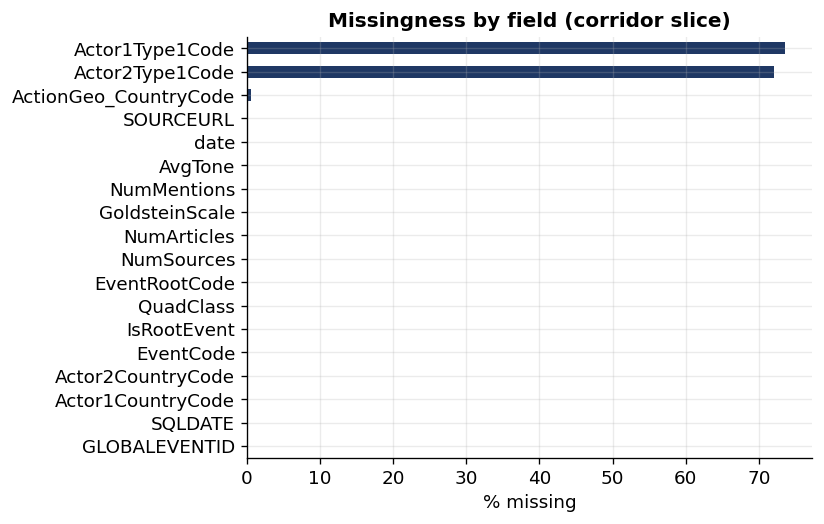

In [10]:
# Country-code fields are notoriously sparse in GDELT (actors often coded without a country)
for c in ["Actor1CountryCode","Actor2CountryCode","ActionGeo_CountryCode"]:
    print(f"{c}: missing {ev[c].isna().mean()*100:.1f}% within the corridor slice")
fig,ax=plt.subplots(figsize=(7,4.5))
(ev.isna().mean()*100).sort_values().plot.barh(ax=ax,color=ACCENT)
ax.set_xlabel("% missing"); ax.set_title("Missingness by field (corridor slice)")
plt.savefig(FIG/"gdelt_missingness.png",bbox_inches="tight"); plt.show()

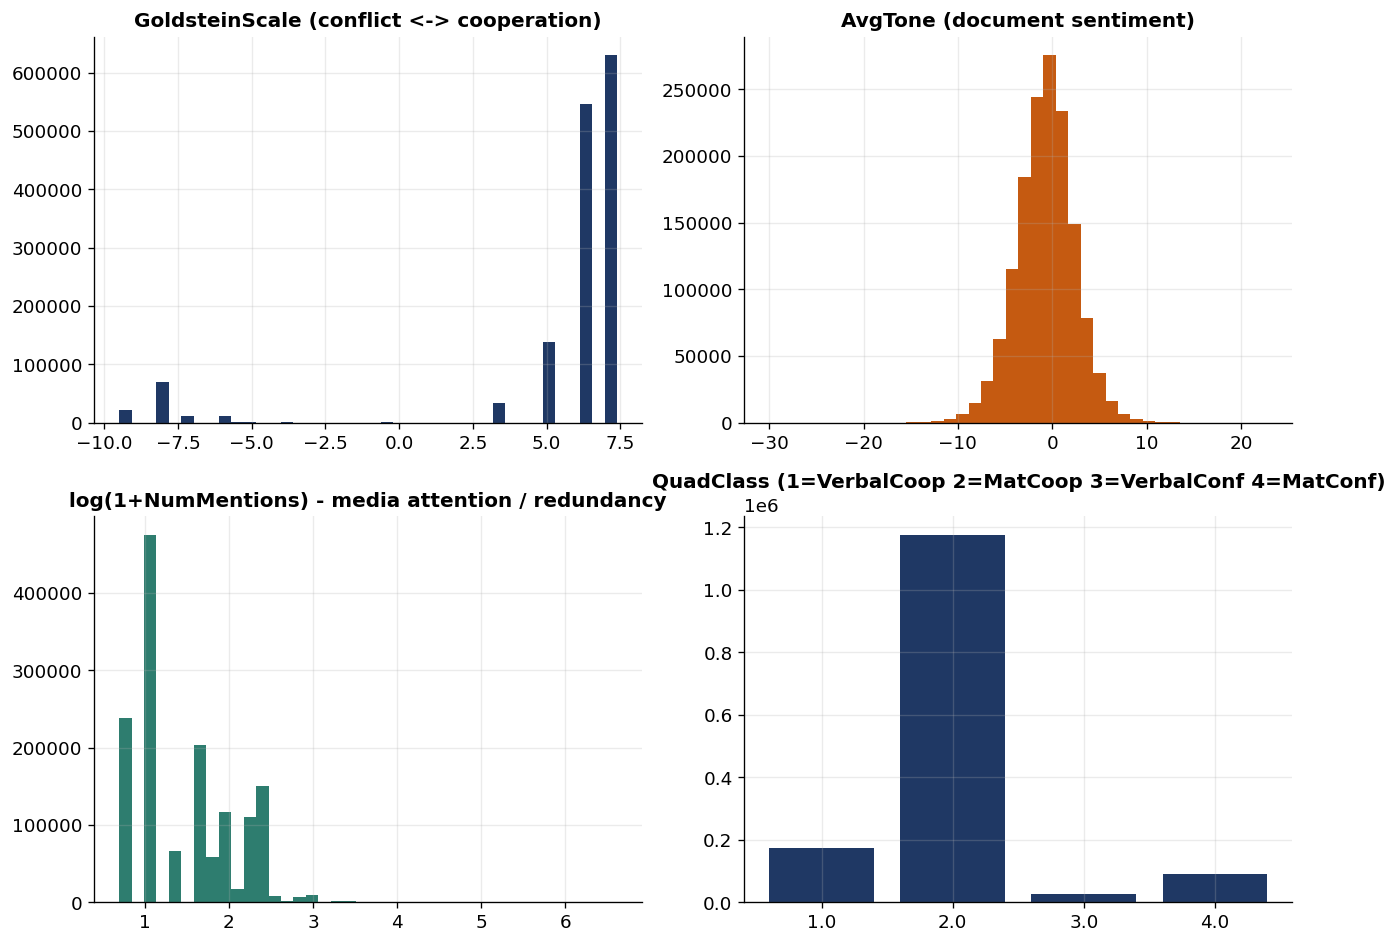

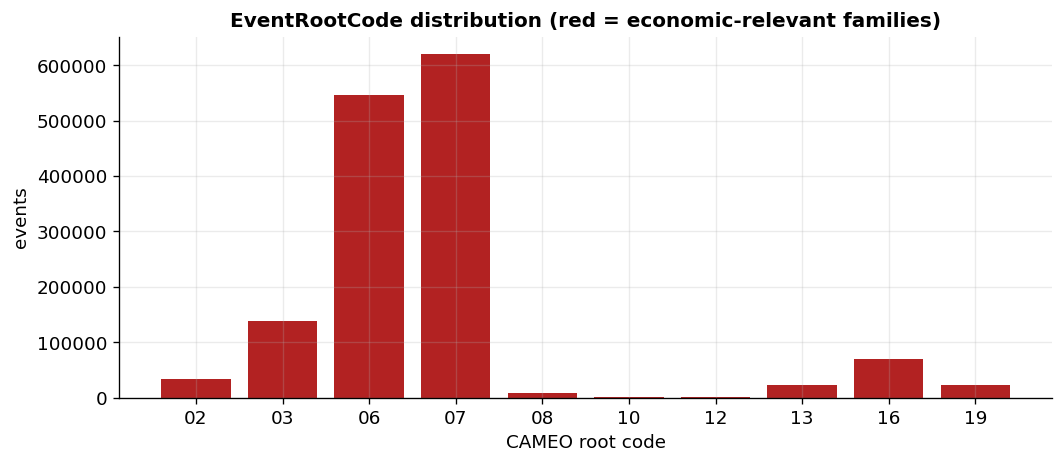

NOTE: this slice is already trade-specific: 1,467,733 events = 2.83% of 51,925,986 corridor events.


In [11]:
fig,axes=plt.subplots(2,2,figsize=(11,8))
axes[0,0].hist(ev['GoldsteinScale'].dropna(),bins=40,color=ACCENT)
axes[0,0].set_title("GoldsteinScale (conflict <-> cooperation)")
axes[0,1].hist(ev['AvgTone'].dropna().clip(-30,30),bins=40,color=ORANGE)
axes[0,1].set_title("AvgTone (document sentiment)")
axes[1,0].hist(np.log1p(ev['NumMentions'].dropna()),bins=40,color=TEAL)
axes[1,0].set_title("log(1+NumMentions) - media attention / redundancy")
qc=ev['QuadClass'].value_counts().sort_index()
axes[1,1].bar(qc.index.astype(str),qc.values,color=ACCENT)
axes[1,1].set_title("QuadClass (1=VerbalCoop 2=MatCoop 3=VerbalConf 4=MatConf)")
plt.savefig(FIG/"gdelt_distributions.png",bbox_inches="tight"); plt.show()

root=ev['EventRootCode'].value_counts().sort_index()
fig,ax=plt.subplots(figsize=(9,4))
econ=[str(r) for r in root.index]
ax.bar(econ,root.values,color=[RED if r in ECON_ROOTCODES else ACCENT for r in econ])
ax.set_title("EventRootCode distribution (red = economic-relevant families)")
ax.set_xlabel("CAMEO root code"); ax.set_ylabel("events")
plt.savefig(FIG/"gdelt_rootcodes.png",bbox_inches="tight"); plt.show()
print(f"NOTE: this slice is already trade-specific: {TRADE_EVENTS:,} events = "
      f"{100*TRADE_EVENTS/ALL_CORRIDOR_EVENTS:.2f}% of {ALL_CORRIDOR_EVENTS:,} corridor events.")

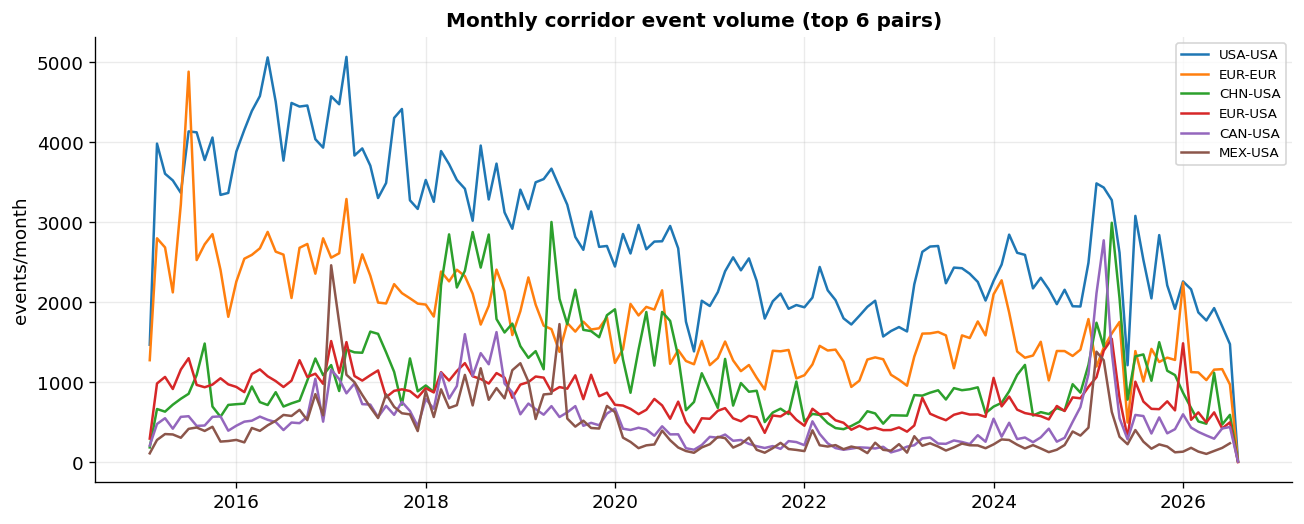

Events per entity pair (top 15):
pair
(USA, USA)    395540
(EUR, EUR)    243726
(CHN, USA)    153347
(EUR, USA)    110773
(CAN, USA)     73231
(MEX, USA)     61170
(CHN, EUR)     48827
(CHN, CHN)     46227
(CAN, CAN)     32779
(JPN, USA)     30347
(CHN, JPN)     24043
(CAN, MEX)     20992
(CAN, CHN)     20356
(CHN, KOR)     17779
(JPN, KOR)     17012


In [12]:
# map each event to an entity pair (both directions collapsed)
code2ent={c:e for e,cs in ENTITY_TO_CODES.items() for c in cs}
ev['e1']=ev['Actor1CountryCode'].map(code2ent); ev['e2']=ev['Actor2CountryCode'].map(code2ent)
ev['pair']=ev.apply(lambda r: tuple(sorted((r['e1'],r['e2']))) if pd.notna(r['e1']) and pd.notna(r['e2']) else None,axis=1)
ev['month']=ev['date'].values.astype('datetime64[M]')
top_pairs=ev['pair'].value_counts().head(6).index.tolist()
fig,ax=plt.subplots(figsize=(11,4.5))
for pr in top_pairs:
    s=ev[ev['pair']==pr].groupby('month').size()
    ax.plot(s.index,s.values,label="-".join(pr))
ax.set_title("Monthly corridor event volume (top 6 pairs)"); ax.set_ylabel("events/month"); ax.legend(fontsize=8)
plt.savefig(FIG/"gdelt_corridor_temporal.png",bbox_inches="tight"); plt.show()
print("Events per entity pair (top 15):")
print(ev['pair'].value_counts().head(15).to_string())

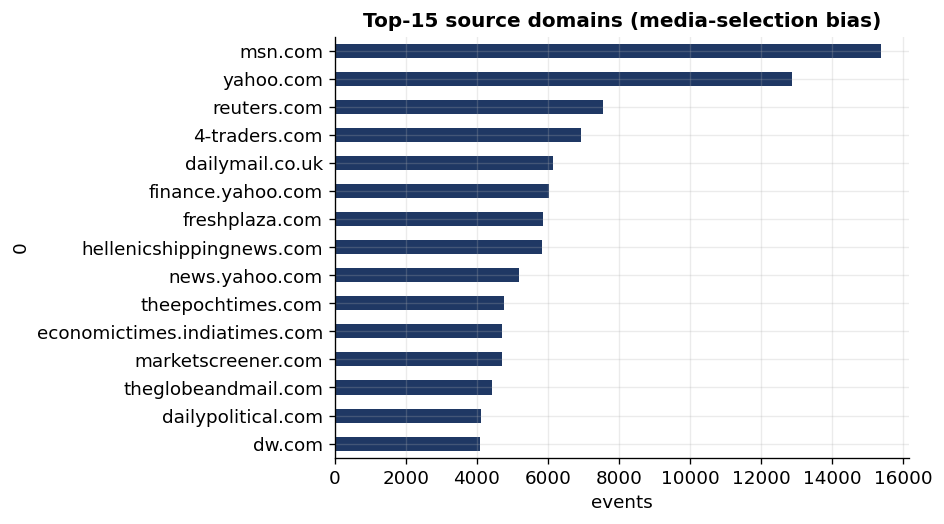

Top-15 domains account for 6.7% of corridor events

IsRootEvent share: 62.1% root events (non-root are repeats within a story -> overcounting)
NumMentions: median 3, p95 10, max 748  (high tail = duplication/attention)

CODE-SYSTEM TRAP: Actor*CountryCode uses CAMEO (e.g., China='CHN'); ActionGeo_CountryCode uses FIPS 10-4 (China='CH', Switzerland='SZ'). Never join them directly. Example ActionGeo codes present: ['CA', 'FR', 'RP', 'SL', 'JA', 'KS', 'BE', 'RS', 'US', 'CH']


In [13]:
# 8a. Source concentration (media-selection bias) via SOURCEURL domain
dom=ev['SOURCEURL'].dropna().str.extract(r'https?://([^/]+)/?')[0].str.replace('www.','',regex=False)
topdom=dom.value_counts().head(15)
fig,ax=plt.subplots(figsize=(8,4.5)); topdom.plot.barh(ax=ax,color=ACCENT); ax.invert_yaxis()
ax.set_title("Top-15 source domains (media-selection bias)"); ax.set_xlabel("events")
plt.savefig(FIG/"gdelt_sources.png",bbox_inches="tight"); plt.show()
print("Top-15 domains account for %.1f%% of corridor events" % (100*topdom.sum()/dom.notna().sum()))

# 8b. Redundancy proxy: NumMentions inflation and IsRootEvent share
print("\nIsRootEvent share:", f"{ev['IsRootEvent'].mean()*100:.1f}% root events "
      "(non-root are repeats within a story -> overcounting)")
print("NumMentions: median %.0f, p95 %.0f, max %.0f  (high tail = duplication/attention)"
      % (ev['NumMentions'].median(), ev['NumMentions'].quantile(.95), ev['NumMentions'].max()))

# 8c. The code-system trap: Actor CountryCode (CAMEO) vs ActionGeo_CountryCode (FIPS 10-4)
print("\nCODE-SYSTEM TRAP: Actor*CountryCode uses CAMEO (e.g., China='CHN'); "
      "ActionGeo_CountryCode uses FIPS 10-4 (China='CH', Switzerland='SZ'). "
      "Never join them directly. Example ActionGeo codes present:",
      list(ev['ActionGeo_CountryCode'].dropna().unique()[:10]))

Loaded slice = 1,467,733 trade-specific events = 2.83% of the 51,925,986 corridor events; the other 97.17% are non-economic and excluded.


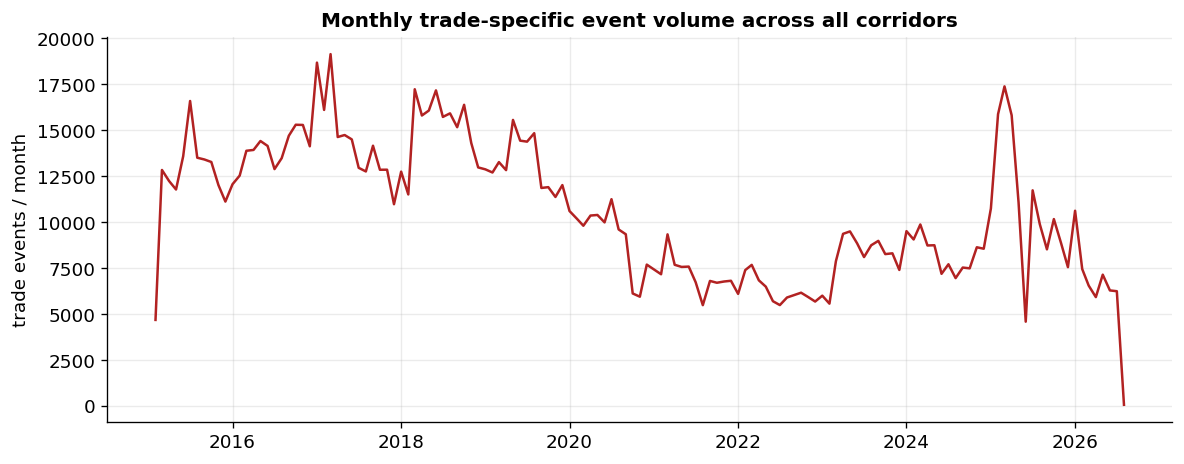

In [14]:
# `ev` is ALREADY the trade-specific slice, so this section reports its share and temporal profile.
share = 100*TRADE_EVENTS/ALL_CORRIDOR_EVENTS
print(f"Loaded slice = {len(ev):,} trade-specific events = {share:.2f}% of the "
      f"{ALL_CORRIDOR_EVENTS:,} corridor events; the other {100-share:.2f}% are non-economic and excluded.")
byq = ev.groupby(ev['date'].values.astype('datetime64[M]')).size()
fig,ax = plt.subplots(figsize=(10,4))
ax.plot(byq.index, byq.values, color=RED)
ax.set_title("Monthly trade-specific event volume across all corridors")
ax.set_ylabel("trade events / month")
plt.savefig(FIG/"gdelt_econ_temporal.png", bbox_inches="tight"); plt.show()

In [15]:

# restrict corridor slice to the 17 Tier-1 pairs (primary corridors)
PAIRS17={frozenset(pr) for pr in TIER1}
mask17=ev['pair'].apply(lambda pr: pr is not None and frozenset(pr) in PAIRS17)
ev17=ev[mask17].copy()
print(f"Corridor events in the 17 Tier-1 pairs: {len(ev17):,} of {len(ev):,} pulled")

tr=ev17[ev17['EventCode'].isin(TRADE_CODES)].copy()
tr['family']=tr['EventCode'].map(CODE_TO_FAMILY)
print(f"Trade-specific events: {len(tr):,}  ({100*len(tr)/max(len(ev17),1):.2f}% of Tier-1 corridor events)")

diag=tr['EventCode'].value_counts().rename('n').to_frame()
diag['desc']=[CAMEO_TRADE[c][0] for c in diag.index]
diag['role']=[CAMEO_TRADE[c][1] for c in diag.index]
diag['share_of_trade_pct']=(100*diag['n']/diag['n'].sum()).round(2)
diag

Corridor events in the 17 Tier-1 pairs: 573,912 of 1,467,733 pulled
Trade-specific events: 573,912  (100.00% of Tier-1 corridor events)


,n,desc,role,share_of_trade_pct
EventCode,,,,
061,322936,Cooperate economically,coop,56.27
071,139031,Provide economic aid,coop,24.23
0311,45520,Express intent to cooperate economically,coop,7.93
163,33723,"Impose embargo, boycott, or sanctions",realized,5.88
0331,6931,Express intent to provide economic aid,coop,1.21
191,6025,"Impose blockade, restrict movement",realized,1.05
0231,5784,Appeal for economic aid,coop,1.01
085,3643,"Ease economic sanctions, boycott, embargo",ease,0.63
1312,3018,"Threaten with sanctions, boycott, embargo",threat,0.53


In [16]:

MIN_STANDALONE = 500   # events across the window & 17 Tier-1 corridors; tune after seeing `diag`
code_n = tr['EventCode'].value_counts()
gran=[]
for code,(desc,role) in CAMEO_TRADE.items():
    n=int(code_n.get(code,0))
    gran.append({'code':code,'family':CODE_TO_FAMILY[code],'role':role,'n':n,
                 'decision':'standalone' if n>=MIN_STANDALONE else 'fold_to_family'})
grandf=pd.DataFrame(gran).sort_values(['family','n'],ascending=[True,False]).reset_index(drop=True)
STANDALONE_CODES=grandf.loc[grandf.decision=='standalone','code'].tolist()
print(f"Standalone codes (n>= {MIN_STANDALONE}): {STANDALONE_CODES}")
print(f"Codes folded into family composites: {grandf.loc[grandf.decision=='fold_to_family','code'].tolist()}")
print("\nFinal feature plan -> for each corridor-month:")
print("  * one count per FEATURE_FAMILY (all codes; guarantees rare-but-relevant signal survives)")
print("  * PLUS a standalone count for each dense code above (extra resolution; model regularises)")
grandf

Standalone codes (n>= 500): ['163', '191', '061', '071', '0311', '0331', '0231', '0211', '085', '1211', '1312', '139', '1313']
Codes folded into family composites: ['1621', '1031', '1054', '1011', '0254', '0354', '1244', '1221', '1311']

Final feature plan -> for each corridor-month:
  * one count per FEATURE_FAMILY (all codes; guarantees rare-but-relevant signal survives)
  * PLUS a standalone count for each dense code above (extra resolution; model regularises)


,code,family,role,n,decision
0,163,econ_coerce,realized,33723,standalone
1,191,econ_coerce,realized,6025,standalone
2,1621,econ_coerce,realized,118,fold_to_family
3,061,econ_coop,coop,322936,standalone
4,071,econ_coop,coop,139031,standalone
5,0311,econ_coop,coop,45520,standalone
6,0331,econ_coop,coop,6931,standalone
7,0231,econ_coop,coop,5784,standalone
8,0211,econ_coop,coop,1970,standalone
9,1031,econ_demand,verbal,236,fold_to_family


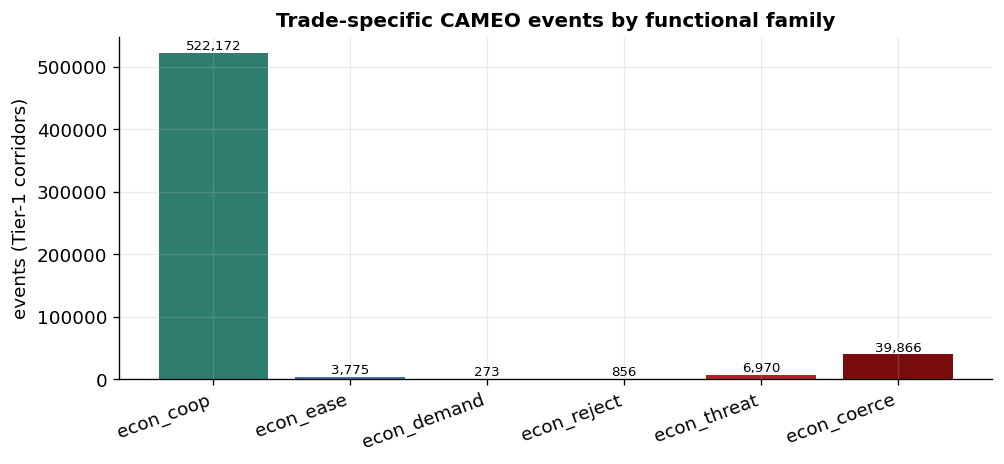

family
econ_coop      522172
econ_ease        3775
econ_demand       273
econ_reject       856
econ_threat      6970
econ_coerce     39866


In [17]:
# family-level view (this is what becomes features)
role_of_family={'econ_coop':'coop','econ_ease':'ease','econ_demand':'verbal',
 'econ_reject':'verbal','econ_threat':'threat','econ_coerce':'realized'}
rolecol={'coop':TEAL,'ease':'#4C72B0','verbal':ORANGE,'threat':'#B22222','realized':'#7A0C0C'}
fam=tr['family'].value_counts().reindex(list(FEATURE_FAMILIES)).fillna(0)
fig,ax=plt.subplots(figsize=(8.5,4))
ax.bar(range(len(fam)),fam.values,color=[rolecol[role_of_family[f]] for f in fam.index])
ax.set_xticks(range(len(fam))); ax.set_xticklabels(fam.index,rotation=20,ha='right')
ax.set_ylabel("events (Tier-1 corridors)")
ax.set_title("Trade-specific CAMEO events by functional family")
for i,v in enumerate(fam.values): ax.text(i,v,f"{int(v):,}",ha='center',va='bottom',fontsize=8)
plt.savefig(FIG/"gdelt_cameo_families.png",bbox_inches="tight"); plt.show()
print(fam.astype(int).to_string())

In [18]:
# bridge to Task 6: corridor-month x family feature matrix (preview)
tr['month']=tr['date'].values.astype('datetime64[M]')
tr['pair_str']=tr['pair'].apply(lambda pr: "-".join(pr))
feat=(tr.pivot_table(index=['pair_str','month'],columns='family',
       values='GLOBALEVENTID',aggfunc='count',fill_value=0)
       .reindex(columns=list(FEATURE_FAMILIES),fill_value=0))
print("Corridor-month feature matrix (trade-specific families):", feat.shape)
print("Sparsity - share of all-zero family cells: %.1f%%" % (100*(feat.values==0).mean()))
feat.head(8)

Corridor-month feature matrix (trade-specific families): (2352, 6)
Sparsity - share of all-zero family cells: 59.2%


family               econ_coop  econ_ease  econ_demand  econ_reject  \
pair_str month                                                        
BRA-CHN  2015-02-01         33          0            0            0   
         2015-03-01         70          0            0            0   
         2015-04-01         70          0            0            0   
         2015-05-01        529          2            0            0   
         2015-06-01        138          0            0            0   
         2015-07-01        115          3            0            0   
         2015-08-01        134          0            0            0   
         2015-09-01         90          0            0            0   

family               econ_threat  econ_coerce  
pair_str month                                 
BRA-CHN  2015-02-01            0            0  
         2015-03-01            0            0  
         2015-04-01            0            0  
         2015-05-01            0            5  
         2015-06-01            0            3  
         2015-07-01            0            0  
         2015-08-01            0            0  
         2015-09-01            0            0

In [19]:
for freq,label in [('W','weekly'),('M','monthly')]:
    g = tr.copy()
    g['bucket'] = g['date'].dt.to_period(freq).dt.to_timestamp()
    m = (g.pivot_table(index=['pair_str','bucket'], columns='family',
                       values='GLOBALEVENTID', aggfunc='count', fill_value=0)
           .reindex(columns=list(FEATURE_FAMILIES), fill_value=0))
    rare = m[['econ_threat','econ_coerce']]
    print(f"{label:8s}: cells {m.shape}, all-zero {100*(m.values==0).mean():.1f}%, "
          f"threat/coerce zero {100*(rare.values==0).mean():.1f}%")

weekly  : cells (9895, 6), all-zero 71.2%, threat/coerce zero 69.9%
monthly : cells (2352, 6), all-zero 59.2%, threat/coerce zero 46.2%


In [20]:
g = tr.copy(); g['bucket'] = g['date'].dt.to_period('W').dt.to_timestamp()
m = (g.pivot_table(index=['pair_str','bucket'], columns='family',
                   values='GLOBALEVENTID', aggfunc='count', fill_value=0)
       .reindex(columns=list(FEATURE_FAMILIES), fill_value=0))
print((m==0).mean().round(3)*100)   # per-family % zero, weekly

family
econ_coop       0.4
econ_ease      91.1
econ_demand    98.6
econ_reject    97.1
econ_threat    82.6
econ_coerce    57.1
dtype: float64
